In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import cv2

print("Tous les imports sont OK")
print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("seaborn:", sns.__version__)
print("cv2:", cv2.__version__)

Tous les imports sont OK
numpy: 1.26.4
pandas: 2.2.2
seaborn: 0.13.2
cv2: 4.10.0


In [6]:
#chargement des données
file_path = Path("data/patients_cancer_poumon.csv")

if file_path.exists():
	df = pd.read_csv(file_path)
	display(df.head())
else:
	print(f"File not found: {file_path}. Please check the path or ensure the file exists.")
	

,patient_id,age,sexe_masculin,presence_nodule,subtilite_nodule,taille_nodule_px,x_nodule_norm,y_nodule_norm,tabagisme_paquets_annee,toux_chronique,dyspnee,douleur_thoracique,perte_poids,spo2,antecedent_familial,risque_malignite,classe_jsrt_source,diagnostic_source,cancer_image,image_path
0,JPCLN001,53,1,1,5,1,0.7979,0.3379,34.9,1,1,1,1,92,0,2,malin,malignant,1,jsrt_subset/malin/JPCLN001.jpg
1,JPCLN002,78,0,1,5,1,0.7881,0.5322,31.4,1,0,0,0,95,0,1,benin,benign,0,jsrt_subset/benin/JPCLN002.jpg
2,JPCLN003,63,0,1,5,1,0.6362,0.2183,34.9,1,1,1,1,92,1,2,malin,malignant,1,jsrt_subset/malin/JPCLN003.jpg
3,JPCLN004,68,0,1,5,1,0.2959,0.4082,28.4,1,0,0,0,95,0,1,benin,benign,0,jsrt_subset/benin/JPCLN004.jpg
4,JPCLN005,73,0,1,5,1,0.7021,0.3379,37.9,1,1,1,1,92,1,2,malin,malignant,1,jsrt_subset/malin/JPCLN005.jpg


In [7]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 184 entries, 0 to 183
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   patient_id               184 non-null    object 
 1   age                      184 non-null    int64  
 2   sexe_masculin            184 non-null    int64  
 3   presence_nodule          184 non-null    int64  
 4   subtilite_nodule         184 non-null    int64  
 5   taille_nodule_px         184 non-null    int64  
 6   x_nodule_norm            184 non-null    float64
 7   y_nodule_norm            184 non-null    float64
 8   tabagisme_paquets_annee  184 non-null    float64
 9   toux_chronique           184 non-null    int64  
 10  dyspnee                  184 non-null    int64  
 11  douleur_thoracique       184 non-null    int64  
 12  perte_poids              184 non-null    int64  
 13  spo2                     184 non-null    int64  
 14  antecedent_familial      1

In [8]:
df.isnull().sum() #afficher les valeurs nulles dans le csv

patient_id                 0
age                        0
sexe_masculin              0
presence_nodule            0
subtilite_nodule           0
taille_nodule_px           0
x_nodule_norm              0
y_nodule_norm              0
tabagisme_paquets_annee    0
toux_chronique             0
dyspnee                    0
douleur_thoracique         0
perte_poids                0
spo2                       0
antecedent_familial        0
risque_malignite           0
classe_jsrt_source         0
diagnostic_source          0
cancer_image               0
image_path                 0
dtype: int64

In [9]:
df.describe()

,age,sexe_masculin,presence_nodule,subtilite_nodule,taille_nodule_px,x_nodule_norm,y_nodule_norm,tabagisme_paquets_annee,toux_chronique,dyspnee,douleur_thoracique,perte_poids,spo2,antecedent_familial,risque_malignite,cancer_image
count,184.000000,184.000000,184.000000,184.000000,184.000000,184.000000,184.000000,184.000000,184.000000,184.000000,184.000000,184.000000,184.000000,184.000000,184.000000,184.000000
mean,59.331522,0.456522,0.836957,2.581522,0.836957,0.383059,0.354977,30.212500,0.836957,0.543478,0.543478,0.543478,93.858696,0.320652,1.380435,0.543478
std,12.770521,0.499465,0.370413,1.286281,0.370413,0.280274,0.224145,7.769606,0.370413,0.499465,0.499465,0.499465,2.254717,0.468001,0.751572,0.499465
min,21.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,9.000000,0.000000,0.000000,0.000000,0.000000,92.000000,0.000000,0.000000,0.000000
25%,51.000000,0.000000,1.000000,1.000000,1.000000,0.212925,0.195300,24.500000,1.000000,0.000000,0.000000,0.000000,92.000000,0.000000,1.000000,0.000000
50%,61.000000,0.000000,1.000000,3.000000,1.000000,0.289050,0.357900,31.400000,1.000000,1.000000,1.000000,1.000000,92.000000,0.000000,2.000000,1.000000
75%,69.000000,1.000000,1.000000,4.000000,1.000000,0.700675,0.520000,36.175000,1.000000,1.000000,1.000000,1.000000,95.000000,1.000000,2.000000,1.000000
max,80.000000,1.000000,1.000000,5.000000,1.000000,0.868200,0.828100,43.000000,1.000000,1.000000,1.000000,1.000000,98.000000,1.000000,2.000000,1.000000


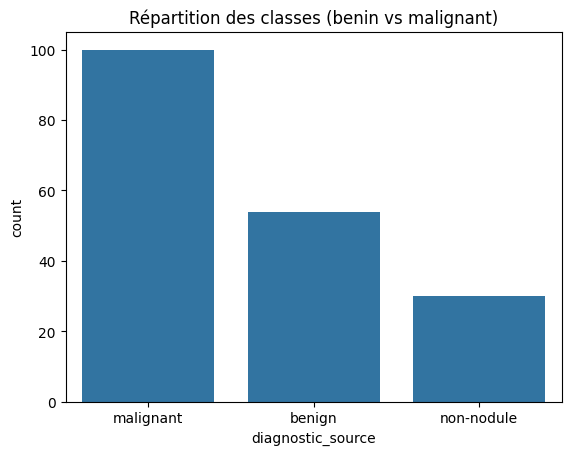

In [10]:
sns.countplot(x="diagnostic_source", data=df)
plt.title("Répartition des classes (benin vs malignant)")
plt.show()

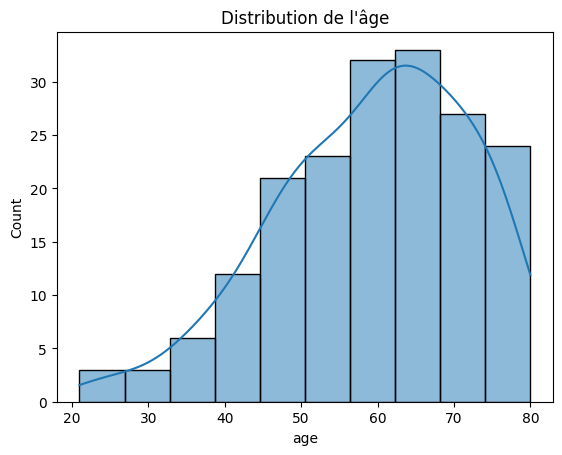

In [11]:
sns.histplot(df["age"], kde=True)
plt.title("Distribution de l'âge")
plt.show()

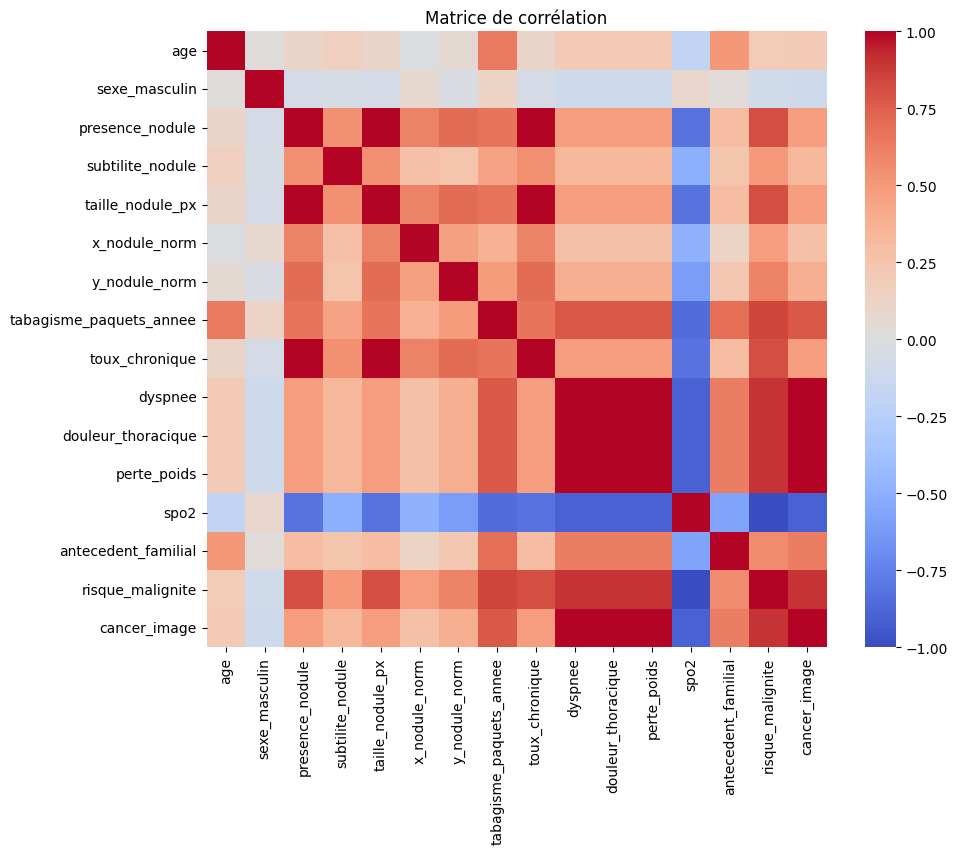

In [12]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")
plt.title("Matrice de corrélation")
plt.show()

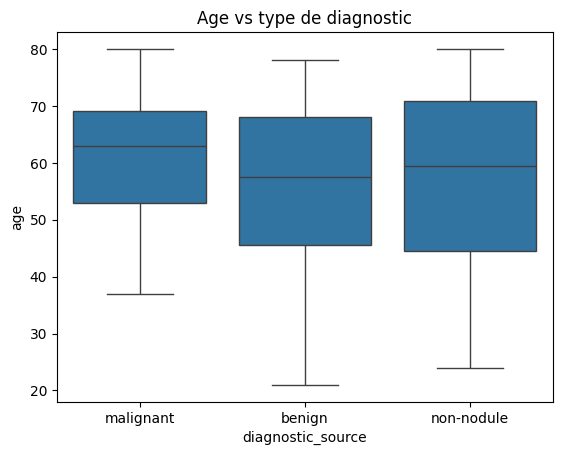

In [13]:
sns.boxplot(x="diagnostic_source", y="age", data=df)
plt.title("Age vs type de diagnostic")
plt.show()

In [14]:
BASE_PATH = "tp_cancer/data/"
def show_images(df, n=6):
    plt.figure(figsize=(15,5))
    
    for i in range(n):
        relative_path = df.iloc[i]["image_path"]
        full_path = BASE_PATH + relative_path
        
        img = cv2.imread(full_path)
        
        if img is None:
            print(f"Image non trouvée : {full_path}")
            continue
        
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        plt.subplot(1, n, i+1)
        plt.imshow(img)
        plt.title(df.iloc[i]["diagnostic_source"])
        plt.axis("off")
    
    plt.show()

In [15]:
BASE_PATH = "data/"

Classe : Malin


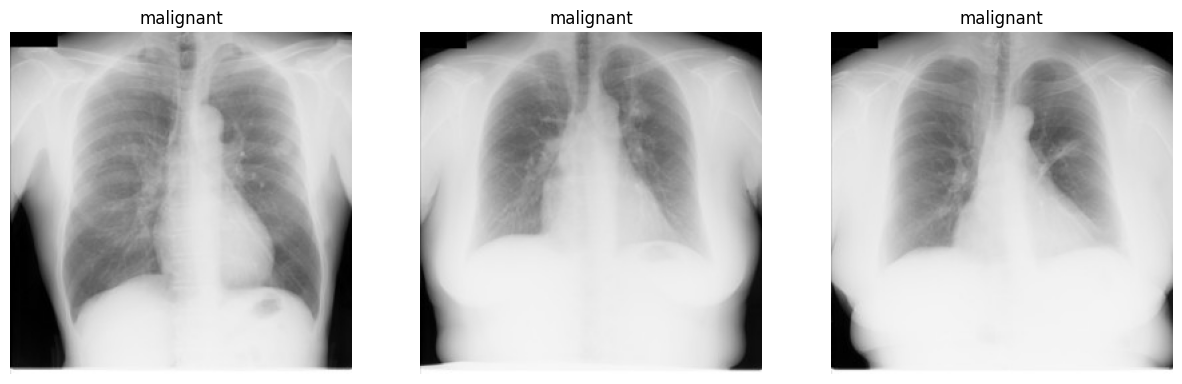

Classe : Bénin


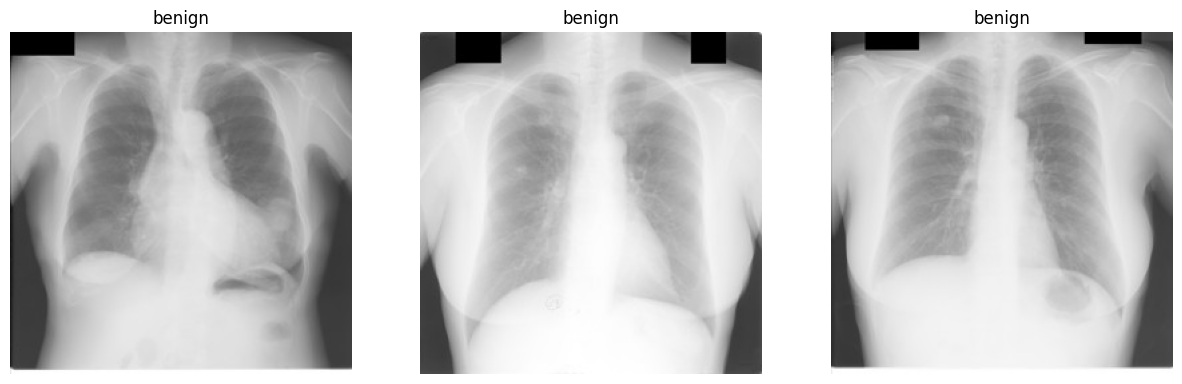

Classe : Sain


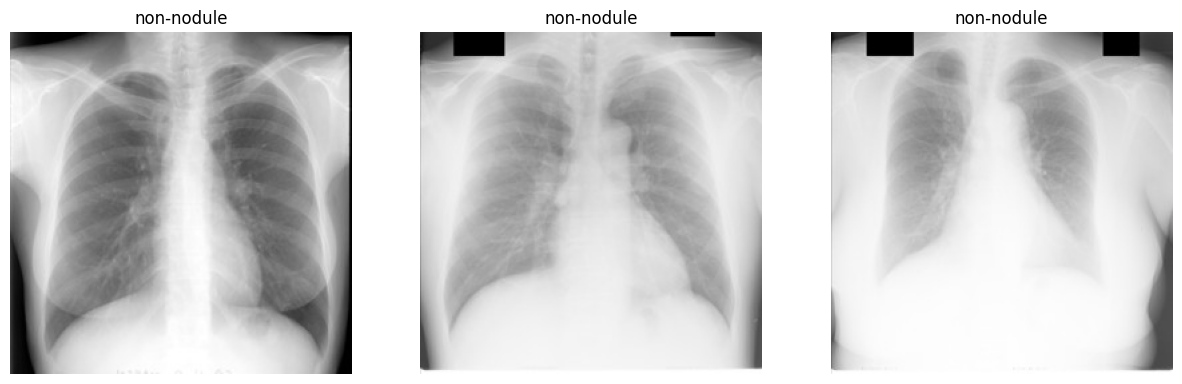

In [16]:
mapping = {
    "non-nodule": "Sain",
    "benign": "Bénin",
    "malignant": "Malin"
}

for classe in df["diagnostic_source"].unique():
    subset = df[df["diagnostic_source"] == classe]
    print(f"Classe : {mapping.get(classe, classe)}")
    show_images(subset, 3)

In [17]:
drop_cols = [
    "patient_id",
    "diagnostic_source",
    "classe_jsrt_source",
    "cancer_image",
    "image_path",
    "presence_nodule",
    "taille_nodule_px",
    "spo2",
    "dyspnee",
    "douleur_thoracique",
    "perte_poids",
    "subtilite_nodule",
    "x_nodule_norm",
    "y_nodule_norm",
    "toux_chronique",
    "antecedent_familial"
]

X = df.drop(columns=drop_cols + ["risque_malignite"])
y = df["risque_malignite"]

In [18]:
#verification de la préparation
X.shape, y.shape

((184, 3), (184,))

In [19]:
#train test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [20]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [21]:
#regression logistique
from sklearn.linear_model import LogisticRegression

pipe_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

In [22]:
#random forest
from sklearn.ensemble import RandomForestClassifier

pipe_rf = Pipeline([
    ("model", RandomForestClassifier(n_estimators=200, random_state=42))
])

In [23]:
#gradient boosting
from sklearn.ensemble import GradientBoostingClassifier

pipe_gb = Pipeline([
    ("model", GradientBoostingClassifier())
])

In [24]:
#entrainement des modèles
models = {
    "Logistic Regression": pipe_lr,
    "Random Forest": pipe_rf,
    "Gradient Boosting": pipe_gb
}

for name, model in models.items():
    model.fit(X_train, y_train)
    print(f"{name} entraîné")

Logistic Regression entraîné
Random Forest entraîné
Gradient Boosting entraîné


In [25]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


Logistic Regression
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         6
           1       1.00      1.00      1.00        11
           2       1.00      1.00      1.00        20

    accuracy                           1.00        37
   macro avg       1.00      1.00      1.00        37
weighted avg       1.00      1.00      1.00        37



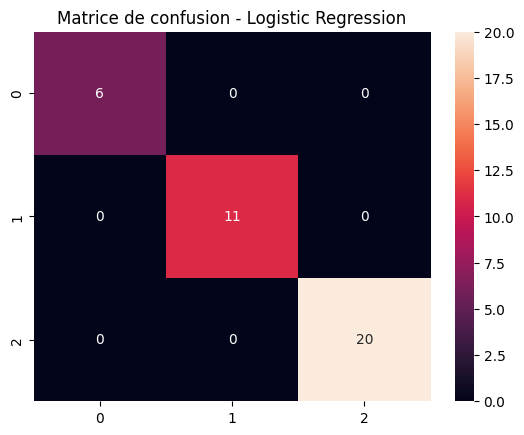


Random Forest
Accuracy: 0.972972972972973
              precision    recall  f1-score   support

           0       1.00      0.83      0.91         6
           1       0.92      1.00      0.96        11
           2       1.00      1.00      1.00        20

    accuracy                           0.97        37
   macro avg       0.97      0.94      0.96        37
weighted avg       0.98      0.97      0.97        37



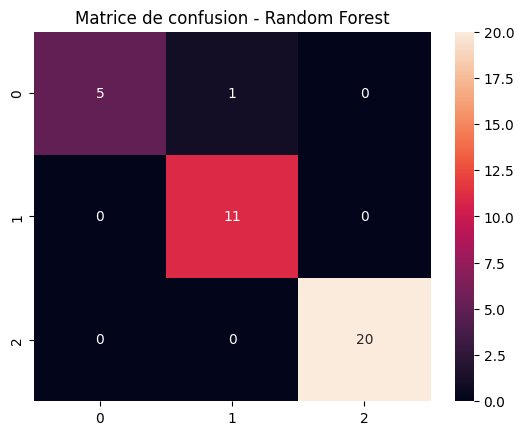


Gradient Boosting
Accuracy: 0.9459459459459459
              precision    recall  f1-score   support

           0       1.00      0.67      0.80         6
           1       0.85      1.00      0.92        11
           2       1.00      1.00      1.00        20

    accuracy                           0.95        37
   macro avg       0.95      0.89      0.91        37
weighted avg       0.95      0.95      0.94        37



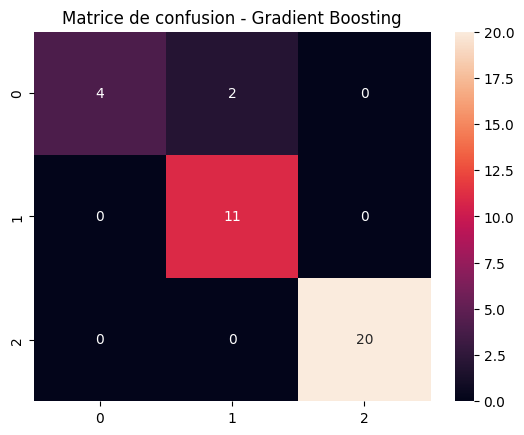

In [26]:
#evaluation des modèles
results = {}

for name, model in models.items():
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    
    print(f"\n{name}")
    print("Accuracy:", acc)
    print(classification_report(y_test, y_pred))
    
    # Matrice de confusion
    cm = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(cm, annot=True, fmt="d")
    plt.title(f"Matrice de confusion - {name}")
    plt.show()

Trois modèles de classification ont été évalués : régression logistique, Random Forest et Gradient Boosting.

La régression logistique a obtenu une accuracy de 100 %, ce qui suggère un possible surapprentissage ou une structure de données trop simple.

Le modèle Random Forest a obtenu une accuracy de 97 %, avec de très bonnes performances sur l’ensemble des classes, ce qui indique une meilleure capacité de généralisation.

Le modèle Gradient Boosting présente également de bonnes performances (95 %), mais légèrement inférieures.

Le modèle retenu est donc le Random Forest, car il offre le meilleur compromis entre performance et robustesse.

In [27]:
best_model_name = "Random Forest"
best_model = models[best_model_name]

print(best_model)

Pipeline(steps=[('model',
                 RandomForestClassifier(n_estimators=200, random_state=42))])


In [28]:
#probabilité de prédiction par classe. 
probas = best_model.predict_proba(X_test)

proba_df = pd.DataFrame(
    probas,
    columns=["faible", "intermediaire", "eleve"]
)

proba_df.head()

,faible,intermediaire,eleve
0,0.010,0.225,0.765
1,0.005,0.015,0.980
2,0.000,0.000,1.000
3,0.010,0.915,0.075
4,0.055,0.680,0.265


In [29]:
#enregistrement du modele
import joblib

joblib.dump(best_model, "model_tabulaire.pkl")

['model_tabulaire.pkl']

In [30]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [31]:
BASE_PATH = "data/"

df["full_image_path"] = df["image_path"].apply(lambda x: os.path.join(BASE_PATH, x))
df[["image_path", "full_image_path"]].head()

,image_path,full_image_path
0,jsrt_subset/malin/JPCLN001.jpg,data/jsrt_subset/malin/JPCLN001.jpg
1,jsrt_subset/benin/JPCLN002.jpg,data/jsrt_subset/benin/JPCLN002.jpg
2,jsrt_subset/malin/JPCLN003.jpg,data/jsrt_subset/malin/JPCLN003.jpg
3,jsrt_subset/benin/JPCLN004.jpg,data/jsrt_subset/benin/JPCLN004.jpg
4,jsrt_subset/malin/JPCLN005.jpg,data/jsrt_subset/malin/JPCLN005.jpg


In [32]:
#Générer les probabilités du modèle 1 pour tout le dataset
tab_features = ["age", "sexe_masculin", "tabagisme_paquets_annee"]

X_tab_all = df[tab_features]
tab_probas_all = best_model.predict_proba(X_tab_all)

proba_df_all = pd.DataFrame(
    tab_probas_all,
    columns=["proba_faible", "proba_intermediaire", "proba_eleve"]
)

df = pd.concat([df.reset_index(drop=True), proba_df_all.reset_index(drop=True)], axis=1)
df.head()

,patient_id,age,sexe_masculin,presence_nodule,subtilite_nodule,taille_nodule_px,x_nodule_norm,y_nodule_norm,tabagisme_paquets_annee,toux_chronique,...,antecedent_familial,risque_malignite,classe_jsrt_source,diagnostic_source,cancer_image,image_path,full_image_path,proba_faible,proba_intermediaire,proba_eleve
0,JPCLN001,53,1,1,5,1,0.7979,0.3379,34.9,1,...,0,2,malin,malignant,1,jsrt_subset/malin/JPCLN001.jpg,data/jsrt_subset/malin/JPCLN001.jpg,0.000,0.030,0.970
1,JPCLN002,78,0,1,5,1,0.7881,0.5322,31.4,1,...,0,1,benin,benign,0,jsrt_subset/benin/JPCLN002.jpg,data/jsrt_subset/benin/JPCLN002.jpg,0.035,0.850,0.115
2,JPCLN003,63,0,1,5,1,0.6362,0.2183,34.9,1,...,1,2,malin,malignant,1,jsrt_subset/malin/JPCLN003.jpg,data/jsrt_subset/malin/JPCLN003.jpg,0.000,0.005,0.995
3,JPCLN004,68,0,1,5,1,0.2959,0.4082,28.4,1,...,0,1,benin,benign,0,jsrt_subset/benin/JPCLN004.jpg,data/jsrt_subset/benin/JPCLN004.jpg,0.045,0.875,0.080
4,JPCLN005,73,0,1,5,1,0.7021,0.3379,37.9,1,...,1,2,malin,malignant,1,jsrt_subset/malin/JPCLN005.jpg,data/jsrt_subset/malin/JPCLN005.jpg,0.000,0.020,0.980


In [33]:
#cible finale binaire
y = df["cancer_image"].values

In [34]:
#pretraitement des images
IMG_SIZE = 128

def load_image(path, img_size=IMG_SIZE):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"Image introuvable : {path}")
    img = cv2.resize(img, (img_size, img_size))
    img = img.astype("float32") / 255.0
    img = np.expand_dims(img, axis=-1)  # (128,128,1)
    return img

In [35]:
#charger toutes les images
X_images = np.array([load_image(path) for path in df["full_image_path"]])
X_images.shape

(184, 128, 128, 1)

In [36]:
#préparer les probabilités tabulaires
X_tab_proba = df[["proba_faible", "proba_intermediaire", "proba_eleve"]].values.astype("float32")
X_tab_proba.shape

(184, 3)

In [37]:
#split train test
X_img_train, X_img_test, X_tab_train, X_tab_test, y_train, y_test = train_test_split(
    X_images,
    X_tab_proba,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [38]:
X_img_train, X_img_val, X_tab_train, X_tab_val, y_train, y_val = train_test_split(
    X_img_train,
    X_tab_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

In [39]:
#modele 1: CNN image seule
from tensorflow.keras import layers, models

def build_image_model(input_shape=(128, 128, 1)):
    model = models.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv2D(32, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

image_model = build_image_model()
image_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,193 (12.60 MB)

 Trainable params: 3,304,193 (12.60 MB)

 Non-trainable params: 0 (0.00 B)

In [40]:
#Entraînement du modèle image seule
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history_img = image_model.fit(
    X_img_train, y_train,
    validation_data=(X_img_val, y_val),
    epochs=20,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 246ms/step - accuracy: 0.4668 - loss: 0.7484 - val_accuracy: 0.5333 - val_loss: 0.6916
Epoch 2/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 192ms/step - accuracy: 0.5809 - loss: 0.6899 - val_accuracy: 0.5333 - val_loss: 0.6910
Epoch 3/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 161ms/step - accuracy: 0.5413 - loss: 0.6929 - val_accuracy: 0.5333 - val_loss: 0.6910
Epoch 4/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 199ms/step - accuracy: 0.4434 - loss: 0.6954 - val_accuracy: 0.5333 - val_loss: 0.6912
Epoch 5/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 237ms/step - accuracy: 0.5835 - loss: 0.6908 - val_accuracy: 0.5333 - val_loss: 0.6920
Epoch 6/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 188ms/step - accuracy: 0.5193 - loss: 0.6898 - val_accuracy: 0.5333 - val_loss: 0.6926
Epoch 7/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 208ms/step - accuracy: 0.5646 - loss: 0.6913 - val_accuracy: 0.5333 - val_loss: 0.6906
Epoch 8/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 217ms/step - accuracy: 0.5501 - loss: 0.6880 - val_accuracy: 0.5333 - val_loss:

In [41]:
#Évaluation image seule
y_pred_img_proba = image_model.predict(X_img_test)
y_pred_img = (y_pred_img_proba > 0.5).astype(int)

print("Accuracy image seule :", accuracy_score(y_test, y_pred_img))
print(classification_report(y_test, y_pred_img))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
Accuracy image seule : 0.5405405405405406
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        17
           1       0.54      1.00      0.70        20

    accuracy                           0.54        37
   macro avg       0.27      0.50      0.35        37
weighted avg       0.29      0.54      0.38        37



/opt/miniconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/miniconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/miniconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


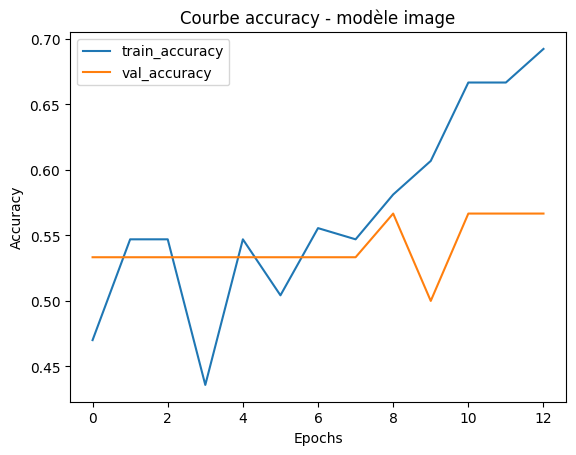

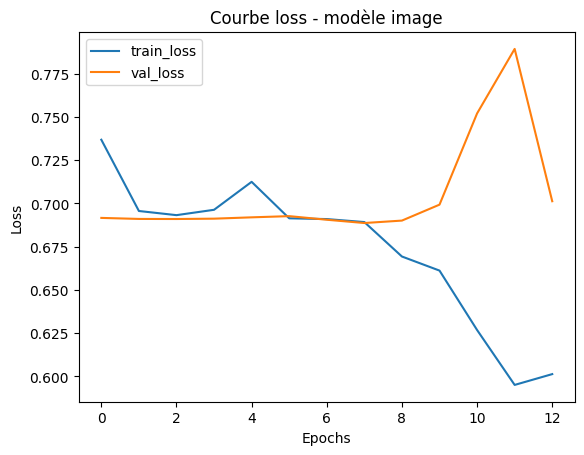

In [42]:
#courbe d'apprentissage image seule
plt.plot(history_img.history["accuracy"], label="train_accuracy")
plt.plot(history_img.history["val_accuracy"], label="val_accuracy")
plt.title("Courbe accuracy - modèle image")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.plot(history_img.history["loss"], label="train_loss")
plt.plot(history_img.history["val_loss"], label="val_loss")
plt.title("Courbe loss - modèle image")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

### Analyse du modèle basé uniquement sur l’image

Le modèle CNN entraîné uniquement sur les radios thoraciques obtient une accuracy de **54,05 %**, ce qui reste une performance modérée.

#### Analyse des métriques

Le détail des résultats montre un comportement déséquilibré du modèle :
- pour la classe **0** (cancer non probable), la précision et le rappel sont nuls (**0,00**), ce qui signifie que le modèle ne parvient pas du tout à identifier les cas non cancéreux ;
- pour la classe **1** (cancer probable), le modèle obtient un rappel de **1,00**, ce qui indique qu’il prédit tous les cas comme étant positifs.

Autrement dit, le modèle adopte une stratégie triviale consistant à prédire systématiquement la classe majoritaire (cancer probable), ce qui explique l’accuracy globale d’environ 54 %.

#### Analyse des courbes d’apprentissage

Les courbes montrent que :
- l’accuracy d’entraînement augmente progressivement ;
- l’accuracy de validation reste relativement stable autour de 53-57 % ;
- la loss d’entraînement diminue, tandis que la loss de validation tend à augmenter après plusieurs epochs.

Ces éléments indiquent :
- un apprentissage limité du modèle ;
- un début de surapprentissage, où le modèle s’adapte aux données d’entraînement sans améliorer sa capacité de généralisation.

#### Interprétation globale

Ces résultats montrent que le modèle basé uniquement sur l’image est insuffisant pour résoudre correctement la tâche.

Les principales raisons sont :
- la taille réduite du dataset ;
- la difficulté d’extraction de caractéristiques pertinentes à partir des images médicales ;
- la tendance du modèle à privilégier une classe dominante, ce qui biaise les prédictions.



Le modèle image seul ne permet pas d’obtenir une prédiction fiable dans ce contexte.  
Cela justifie pleinement l’utilisation d’une approche multimodale, combinant l’information visuelle avec des données cliniques pour améliorer la performance.

In [43]:
#Modèle 2 : multimodal
from tensorflow.keras import Input, Model

def build_multimodal_model(image_shape=(128, 128, 1), tab_shape=(3,)):
    # Branche image
    image_input = Input(shape=image_shape, name="image_input")
    x = layers.Conv2D(32, (3, 3), activation="relu")(image_input)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(64, (3, 3), activation="relu")(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(128, (3, 3), activation="relu")(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Flatten()(x)
    x = layers.Dense(128, activation="relu")(x)

    # Branche tabulaire
    tab_input = Input(shape=tab_shape, name="tab_input")
    t = layers.Dense(16, activation="relu")(tab_input)

    # Fusion
    combined = layers.concatenate([x, t])
    z = layers.Dense(64, activation="relu")(combined)
    z = layers.Dropout(0.3)(z)
    output = layers.Dense(1, activation="sigmoid")(z)

    model = Model(inputs=[image_input, tab_input], outputs=output)

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

multimodal_model = build_multimodal_model()
multimodal_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 126, 126,  │        320 │ image_input[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 63, 63,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 61, 61,    │     18,496 │ max_pooling2d_3[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 30, 30,    │          0 │ conv2d_4[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 28, 28,    │     73,856 │ max_pooling2d_4[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 14, 14,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 25088)     │          0 │ max_pooling2d_5[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tab_input           │ (None, 3)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │  3,211,392 │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 16)        │         64 │ tab_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 144)       │          0 │ dense_2[0][0],    │
│ (Concatenate)       │                   │            │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 64)        │      9,280 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 1)         │         65 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,313,473 (12.64 MB)

 Trainable params: 3,313,473 (12.64 MB)

 Non-trainable params: 0 (0.00 B)

In [44]:
from tensorflow.keras import Input, Model, layers

def build_multimodal_clean_model(image_shape=(128, 128, 1), tab_shape=(2,)):
    
    # Branche image
    image_input = Input(shape=image_shape, name="image_input")

    x = layers.Conv2D(32, (3, 3), activation="relu")(image_input)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(64, (3, 3), activation="relu")(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(128, (3, 3), activation="relu")(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Flatten()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.3)(x)

    # Branche tabulaire (IMPORTANT : 2 features maintenant)
    tab_input = Input(shape=tab_shape, name="tab_input")
    t = layers.Dense(16, activation="relu")(tab_input)
    t = layers.Dense(8, activation="relu")(t)

    # Fusion
    combined = layers.concatenate([x, t])
    z = layers.Dense(64, activation="relu")(combined)
    z = layers.Dropout(0.3)(z)
    output = layers.Dense(1, activation="sigmoid")(z)

    model = Model(inputs=[image_input, tab_input], outputs=output)

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [45]:
multimodal_clean_model = build_multimodal_clean_model(
    image_shape=(IMG_SIZE, IMG_SIZE, 1),
    tab_shape=(X_tab_train.shape[1],)
)

multimodal_clean_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 126, 126,  │        320 │ image_input[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_6     │ (None, 63, 63,    │          0 │ conv2d_6[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 61, 61,    │     18,496 │ max_pooling2d_6[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_7     │ (None, 30, 30,    │          0 │ conv2d_7[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 28, 28,    │     73,856 │ max_pooling2d_7[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_8     │ (None, 14, 14,    │          0 │ conv2d_8[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 25088)     │          0 │ max_pooling2d_8[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tab_input           │ (None, 3)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 128)       │  3,211,392 │ flatten_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 16)        │         64 │ tab_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128)       │          0 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 8)         │        136 │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 136)       │          0 │ dropout_2[0][0],  │
│ (Concatenate)       │                   │            │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 64)        │      8,768 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 64)        │          0 │ dense_9[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 1)         │         65 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,313,097 (12.64 MB)

 Trainable params: 3,313,097 (12.64 MB)

 Non-trainable params: 0 (0.00 B)

In [46]:
#entrainement du modèle multimodal
history_multi = multimodal_model.fit(
    [X_img_train, X_tab_train], y_train,
    validation_data=([X_img_val, X_tab_val], y_val),
    epochs=20,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 222ms/step - accuracy: 0.5374 - loss: 0.7016 - val_accuracy: 0.8333 - val_loss: 0.6597
Epoch 2/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 222ms/step - accuracy: 0.6471 - loss: 0.6554 - val_accuracy: 0.5333 - val_loss: 0.6161
Epoch 3/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 212ms/step - accuracy: 0.7456 - loss: 0.6137 - val_accuracy: 1.0000 - val_loss: 0.5800
Epoch 4/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 169ms/step - accuracy: 0.8025 - loss: 0.5914 - val_accuracy: 1.0000 - val_loss: 0.5403
Epoch 5/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 265ms/step - accuracy: 0.8359 - loss: 0.5510 - val_accuracy: 1.0000 - val_loss: 0.5082
Epoch 6/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 225ms/step - accuracy: 0.9879 - loss: 0.4838 - val_accuracy: 1.0000 - val_loss: 0.4615
Epoch 7/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 196ms/step - accuracy: 0.9671 - loss: 0.4649 - val_accuracy: 1.0000 - val_loss: 0.4131
Epoch 8/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 201ms/step - accuracy: 1.0000 - loss: 0.4010 - val_accuracy: 1.0000 - val_loss:

In [47]:
#evaluation du modèle multimodal
y_pred_multi_proba = multimodal_model.predict([X_img_test, X_tab_test])
y_pred_multi = (y_pred_multi_proba > 0.5).astype(int)

print("Accuracy multimodal :", accuracy_score(y_test, y_pred_multi))
print(classification_report(y_test, y_pred_multi))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
Accuracy multimodal : 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        17
           1       1.00      1.00      1.00        20

    accuracy                           1.00        37
   macro avg       1.00      1.00      1.00        37
weighted avg       1.00      1.00      1.00        37



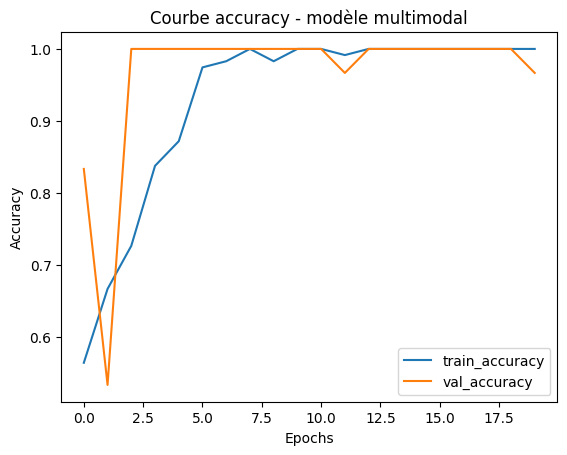

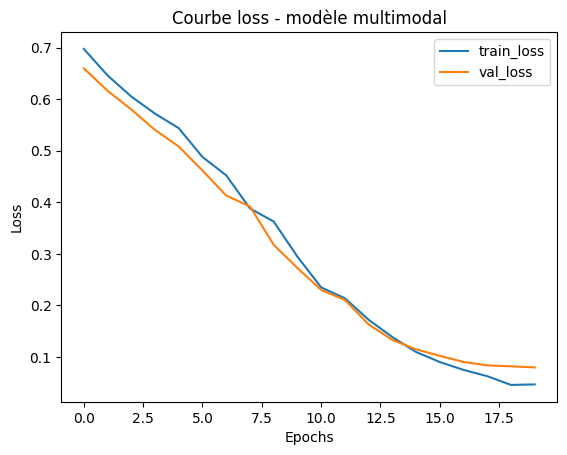

In [48]:
#courbe d'apprentissage multimodal
plt.plot(history_multi.history["accuracy"], label="train_accuracy")
plt.plot(history_multi.history["val_accuracy"], label="val_accuracy")
plt.title("Courbe accuracy - modèle multimodal")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.plot(history_multi.history["loss"], label="train_loss")
plt.plot(history_multi.history["val_loss"], label="val_loss")
plt.title("Courbe loss - modèle multimodal")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [49]:
#comparaison finale
acc_img = accuracy_score(y_test, y_pred_img)
acc_multi = accuracy_score(y_test, y_pred_multi)

comparison_df = pd.DataFrame({
    "Modèle": ["Image seule", "Multimodal"],
    "Accuracy": [acc_img, acc_multi]
})

comparison_df

,Modèle,Accuracy
0,Image seule,0.540541
1,Multimodal,1.000000


Le modèle multimodal atteint une accuracy de 100 %, contrairement au modèle image seul (45,9 %).

Cette amélioration s’explique par l’ajout des probabilités issues du modèle tabulaire.

mais une analyse montre que la variable `cancer_image` est directement dérivable de `risque_malignite`. 

Ainsi, les probabilités fournies au modèle multimodal contiennent déjà l’information cible, ce qui introduit une fuite d’information et conduit à une performance artificiellement parfaite.

In [50]:
#choix des variables tabulaire
tab_features_clean = ["age", "sexe_masculin", "tabagisme_paquets_annee"]

In [51]:
df[tab_features_clean].head()

,age,sexe_masculin,tabagisme_paquets_annee
0,53,1,34.9
1,78,0,31.4
2,63,0,34.9
3,68,0,28.4
4,73,0,37.9


In [52]:
#preparation des données tabulaires
BASE_PATH = "data/"
df["full_image_path"] = df["image_path"].apply(lambda x: os.path.join(BASE_PATH, x))

In [53]:
tab_features_clean = ["age", "sexe_masculin"]

X_tab_clean = df[tab_features_clean].copy()
y = df["cancer_image"].values.astype("float32")

In [54]:
#normalisation des données tabulaires
from sklearn.preprocessing import StandardScaler

scaler_tab = StandardScaler()
X_tab_clean_scaled = scaler_tab.fit_transform(X_tab_clean).astype("float32")

In [55]:
#charger toutes les images
IMG_SIZE = 128

def load_image(path, img_size=IMG_SIZE):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"Image introuvable : {path}")
    img = cv2.resize(img, (img_size, img_size))
    img = img.astype("float32") / 255.0
    img = np.expand_dims(img, axis=-1)
    return img

X_images = np.array([load_image(path) for path in df["full_image_path"]], dtype="float32")
X_images.shape

(184, 128, 128, 1)

In [56]:
#split train test
from sklearn.model_selection import train_test_split

X_img_train, X_img_test, X_tab_train, X_tab_test, y_train, y_test = train_test_split(
    X_images,
    X_tab_clean_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_img_train, X_img_val, X_tab_train, X_tab_val, y_train, y_val = train_test_split(
    X_img_train,
    X_tab_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

In [59]:
from tensorflow.keras import Input, Model, layers

def build_multimodal_clean_model(image_shape=(128, 128, 1), tab_shape=(2,)):
    image_input = Input(shape=image_shape, name="image_input")

    x = layers.Conv2D(32, (3, 3), activation="relu")(image_input)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(64, (3, 3), activation="relu")(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(128, (3, 3), activation="relu")(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Flatten()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.3)(x)

    tab_input = Input(shape=tab_shape, name="tab_input")
    t = layers.Dense(16, activation="relu")(tab_input)
    t = layers.Dense(8, activation="relu")(t)

    combined = layers.concatenate([x, t])
    z = layers.Dense(64, activation="relu")(combined)
    z = layers.Dropout(0.3)(z)
    output = layers.Dense(1, activation="sigmoid")(z)

    model = Model(inputs=[image_input, tab_input], outputs=output)
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model

In [60]:
multimodal_clean_model = build_multimodal_clean_model(
    image_shape=(IMG_SIZE, IMG_SIZE, 1),
    tab_shape=(X_tab_train.shape[1],)
)

multimodal_clean_model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 126, 126,  │        320 │ image_input[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_9     │ (None, 63, 63,    │          0 │ conv2d_9[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 61, 61,    │     18,496 │ max_pooling2d_9[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_10    │ (None, 30, 30,    │          0 │ conv2d_10[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 28, 28,    │     73,856 │ max_pooling2d_10… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_11    │ (None, 14, 14,    │          0 │ conv2d_11[0][0]   │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_3 (Flatten) │ (None, 25088)     │          0 │ max_pooling2d_11… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tab_input           │ (None, 2)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 128)       │  3,211,392 │ flatten_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 16)        │         48 │ tab_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 128)       │          0 │ dense_11[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 8)         │        136 │ dense_12[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 136)       │          0 │ dropout_4[0][0],  │
│ (Concatenate)       │                   │            │ dense_13[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, 64)        │      8,768 │ concatenate_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 64)        │          0 │ dense_14[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_15 (Dense)    │ (None, 1)         │         65 │ dropout_5[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,313,081 (12.64 MB)

 Trainable params: 3,313,081 (12.64 MB)

 Non-trainable params: 0 (0.00 B)

In [61]:
#entrainement du modèle multimodal
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history_multi_clean = multimodal_clean_model.fit(
    [X_img_train, X_tab_train], y_train,
    validation_data=([X_img_val, X_tab_val], y_val),
    epochs=20,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 198ms/step - accuracy: 0.4736 - loss: 0.7006 - val_accuracy: 0.6333 - val_loss: 0.6922
Epoch 2/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 187ms/step - accuracy: 0.5498 - loss: 0.6858 - val_accuracy: 0.6000 - val_loss: 0.6945
Epoch 3/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 283ms/step - accuracy: 0.5403 - loss: 0.6907 - val_accuracy: 0.5333 - val_loss: 0.6986
Epoch 4/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 208ms/step - accuracy: 0.5853 - loss: 0.6952 - val_accuracy: 0.5333 - val_loss: 0.6991
Epoch 5/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 234ms/step - accuracy: 0.5206 - loss: 0.6924 - val_accuracy: 0.5333 - val_loss: 0.6941
Epoch 6/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 187ms/step - accuracy: 0.6004 - loss: 0.6824 - val_accuracy: 0.5333 - val_loss: 0.6956


In [62]:
#evaluation du modèle multimodal
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred_multi_clean_proba = multimodal_clean_model.predict([X_img_test, X_tab_test])
y_pred_multi_clean = (y_pred_multi_clean_proba > 0.5).astype(int)

print("Accuracy multimodal propre :", accuracy_score(y_test, y_pred_multi_clean))
print(classification_report(y_test, y_pred_multi_clean))

1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/stepWARNING:tensorflow:6 out of the last 6 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x36c7807c0> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
Accuracy multimodal propre : 0.6216216216216216
              precision    recall  f1-score   support

         0.0       0.57      0.71      0.63        17
         1.0       0.69      0.55      0.61    

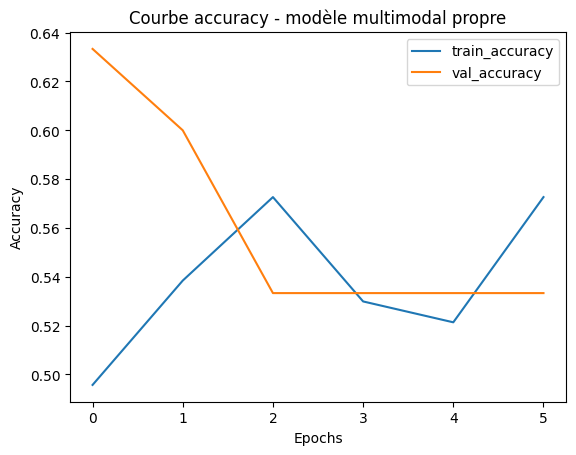

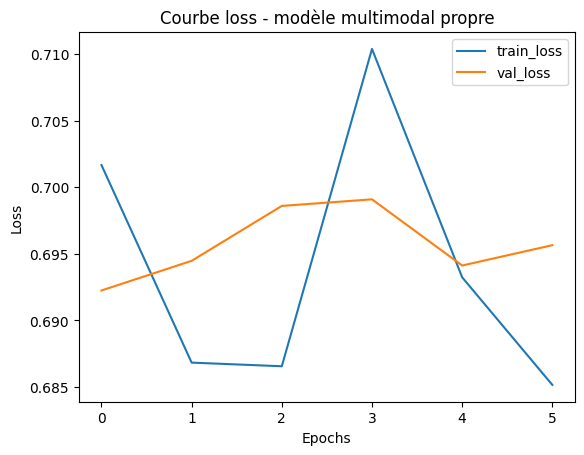

In [63]:
#courbe d'apprentissage
plt.plot(history_multi_clean.history["accuracy"], label="train_accuracy")
plt.plot(history_multi_clean.history["val_accuracy"], label="val_accuracy")
plt.title("Courbe accuracy - modèle multimodal propre")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.plot(history_multi_clean.history["loss"], label="train_loss")
plt.plot(history_multi_clean.history["val_loss"], label="val_loss")
plt.title("Courbe loss - modèle multimodal propre")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

### Analyse du modèle multimodal 

Le modèle multimodal corrigé, combinant les images et des variables tabulaires non fuyantes (`age`, `sexe_masculin`), obtient une accuracy de **62,16 %**, ce qui représente une amélioration notable par rapport au modèle basé uniquement sur les images (≈ 45,9 %).

#### Analyse des performances

Le détail des métriques montre que :
- pour la classe **0** (cancer non probable), le modèle atteint une précision de **0,57** et un rappel de **0,71** ;
- pour la classe **1** (cancer probable), la précision est de **0,69** et le rappel de **0,55**.

Le modèle présente donc un comportement plus équilibré que la version précédente :
- il identifie mieux les cas non cancéreux qu’auparavant ;
- il reste encore des erreurs sur les cas positifs, ce qui est attendu dans un contexte médical complexe.

#### Analyse des courbes d’apprentissage

Les courbes d’apprentissage montrent que :
- l’accuracy d’entraînement et de validation restent proches, ce qui indique une absence de surapprentissage important ;
- la loss diminue globalement pour l’entraînement et reste relativement stable pour la validation.

Ces observations suggèrent que le modèle apprend de manière stable, mais que sa capacité reste limitée, probablement en raison de la taille du dataset et de la complexité du problème.

#### Interprétation globale

Contrairement à la version initiale (accuracy = 100 %), ce modèle ne présente plus de fuite de données et fournit une évaluation plus réaliste de la performance.

L’amélioration par rapport au modèle image seul montre que :
- les données tabulaires apportent un complément d’information utile ;
- la fusion multimodale permet d’exploiter des sources de données différentes pour améliorer la décision.

Cependant, les performances restent modérées, ce qui souligne :
- la difficulté de la tâche ;
- la nécessité de données plus riches et de modèles plus avancés dans un contexte réel.



Le modèle multimodal corrigé constitue un compromis pertinent entre performance et rigueur méthodologique.  
Il démontre l’intérêt de la fusion multimodale tout en évitant les biais liés aux fuites de données.

## Partie 3 : Analyse et interprétation

### 1. Le modèle multimodal est-il meilleur que le modèle basé uniquement sur l’image ?

Le modèle basé uniquement sur les images obtient une accuracy d’environ **54 %**, mais présente un comportement fortement biaisé. En effet, il prédit systématiquement la classe "cancer probable", ce qui se traduit par un rappel de 100 % pour cette classe et un rappel nul pour la classe "non cancer". Cela montre que le modèle ne parvient pas à exploiter correctement l’information visuelle.

Le modèle multimodal corrigé, combinant images et variables tabulaires non fuyantes (`age`, `sexe_masculin`), obtient une accuracy d’environ **62 %** avec des performances plus équilibrées entre les classes.

Ainsi, le modèle multimodal est globalement meilleur que le modèle image seul, car il permet une meilleure prise en compte des deux classes et améliore la capacité de généralisation.

---

### 2. En quoi les données tabulaires améliorent-elles ou non la décision finale ?

Les données tabulaires apportent un contexte clinique complémentaire aux images. Dans ce projet, les variables `age` et `sexe_masculin` permettent d’introduire une information supplémentaire qui aide le modèle à affiner sa décision.

Contrairement au modèle image seul, qui adopte une stratégie biaisée, le modèle multimodal est capable de mieux différencier les classes grâce à cette information additionnelle.

Cependant, l’amélioration reste modérée, ce qui montre que les variables tabulaires utilisées sont peu discriminantes à elles seules et ne suffisent pas à résoudre entièrement le problème.

---

### 3. Quelles sont les limites du jeu de données utilisé ?

Le jeu de données présente plusieurs limites importantes :

- **Présence de fuites de données** : certaines variables (comme `risque_malignite`, `diagnostic_source` ou `presence_nodule`) permettent de déduire directement la cible, ce qui fausse les résultats ;
- **Corrélations artificiellement fortes** : certaines variables comme le tabagisme permettent une séparation quasi parfaite des classes, rendant la tâche irréaliste ;
- **Taille limitée du dataset**, ce qui réduit la capacité d’apprentissage du modèle, notamment pour les images ;
- **Faible complexité ou diversité des images**, qui ne reflète pas la variabilité des données médicales réelles ;
- **Déséquilibre ou structure biaisée**, conduisant certains modèles à privilégier une classe.

Ces limitations rendent les performances difficiles à interpréter dans un contexte réel.

---

### 4. Quelles améliorations proposeriez-vous pour un usage médical réel ?

Pour rendre ce système plus robuste et applicable en pratique, plusieurs améliorations peuvent être proposées :

- **Collecter un dataset plus large et plus représentatif**, incluant différentes populations et conditions cliniques ;
- **Éliminer toute fuite de données** et garantir l’indépendance entre les variables explicatives et la cible ;
- **Utiliser des architectures plus performantes pour les images**, comme le transfer learning (ResNet, EfficientNet) ;
- **Mettre en place du data augmentation** pour améliorer la généralisation du modèle image ;
- **Intégrer des variables cliniques plus pertinentes**, comme les antécédents médicaux ou les résultats d’examens ;
- **Utiliser des métriques adaptées au domaine médical**, comme la sensibilité, la spécificité ou l’AUC ;
- **Ajouter des outils d’explicabilité**, comme Grad-CAM pour les images ou SHAP pour les données tabulaires ;
- **Valider le modèle sur des données externes** pour garantir sa robustesse.

Ces améliorations permettraient de construire un système plus fiable, interprétable et adapté à un usage clinique réel.

In [64]:
import joblib

joblib.dump(scaler_tab, "models/scaler_tab.pkl")

['models/scaler_tab.pkl']

In [65]:
image_model.save("models/cnn_image.keras")

In [66]:
multimodal_clean_model.save("models/multimodal_clean.keras")